# 01 — Basic Retrieval-Augmented Generation

**CIAL Knowledge OS** · local-only · offline-first · model-agnostic

This notebook is a learning and orchestration layer. Reusable implementation lives in `src/cial_knowledge_os`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

## 1. Objective

Build and inspect a baseline local RAG pipeline over small, non-sensitive airport documents. The experiment covers document loading, metadata-preserving chunking, local embeddings, embedded Qdrant retrieval, bounded context construction, grounded Ollama generation, citations, and timing.

Success means evidence is visible before generation, missing evidence produces a safe failure, and the notebook runs top-to-bottom from a fresh kernel.

## 2. Theory

Retrieval-Augmented Generation separates knowledge lookup from language generation:

1. Split documents into bounded, overlapping chunks.
2. Embed chunks and questions with the same local model.
3. Retrieve the nearest chunks from a local vector store.
4. Send only the most relevant evidence to the local LLM.
5. Cite that evidence or explicitly report that the answer is unavailable.

This notebook establishes a dense-retrieval baseline. Hybrid retrieval, metadata authorization, reranking, verification, and conflict handling are later improvements.

## 3. Architecture

```mermaid
flowchart LR
    A[Local TXT and PDF] --> B[Load]
    B --> C[Chunk]
    C --> D[Local embeddings]
    D --> E[Embedded Qdrant]
    Q[Question] --> F[Retrieve]
    E --> F
    F --> G[Bounded cited context]
    G --> H[Local Ollama model]
    H --> I[Grounded answer]
```

Documents, vectors, prompts, and generated text remain on the workstation. Models and paths are selected through configuration.

## 4. Implementation

### Setup

Import reusable project APIs plus matplotlib for notebook display.

In [2]:
import matplotlib.pyplot as plt

from cial_knowledge_os import (
    BasicRAGPipeline, KnowledgeOSConfig, Timer,
    create_local_llm, create_sample_airport_documents,
    format_retrieved_context, generate_answer, load_embedding_model,
    plot_chunk_size_distribution, plot_retrieval_scores,
    plot_timing_breakdown, print_benchmark_table,
    print_retrieval_results, summarize_chunks, summarize_documents,
)

### Configuration

Use one configuration object for local paths, models, chunking, retrieval depth, and context limits.

In [3]:
config = KnowledgeOSConfig(project_root=PROJECT_ROOT)

Display a compact configuration summary using repository-relative paths.

In [4]:
config_summary = {
    "sample_dir": config.sample_data_dir.relative_to(PROJECT_ROOT).as_posix(),
    "pdf_dir": config.pdf_data_dir.relative_to(PROJECT_ROOT).as_posix(),
    "qdrant_dir": config.qdrant_dir.relative_to(PROJECT_ROOT).as_posix(),
    "embedding_model": config.embedding_model_name,
    "embedding_device": config.embedding_device,
    "ollama_model": config.ollama_model_name,
    "chunk_size": config.chunk_size,
    "chunk_overlap": config.chunk_overlap,
    "top_k": config.top_k,
    "max_context_chars": config.max_context_chars,
}
config_summary

{'sample_dir': 'data/sample',
 'pdf_dir': 'data/pdf',
 'qdrant_dir': 'data/qdrant/cial_basic_rag',
 'embedding_model': 'BAAI/bge-m3',
 'embedding_device': 'auto',
 'ollama_model': 'gemma3:4b',
 'chunk_size': 700,
 'chunk_overlap': 120,
 'top_k': 3,
 'max_context_chars': 3000}

### Sample Documents

Create the small versioned sample corpus when absent. Existing sample files are not overwritten.

In [5]:
sample_paths = create_sample_airport_documents(config)
[path.relative_to(PROJECT_ROOT).as_posix() for path in sample_paths]

['data/sample/terminal_operations_sop.txt',
 'data/sample/runway_maintenance_sop.txt',
 'data/sample/electrical_maintenance_manual.txt']

### Data Loading

Load sample and runtime text documents plus optional PDFs from `data/pdf/`. PDF processing is local: Docling is preferred and PyMuPDF is the fallback. With no PDFs, sample documents keep the experiment runnable.

In [6]:
pipeline = BasicRAGPipeline(config)

Run the local loaders through the reusable pipeline.

In [7]:
documents = pipeline.load()

[INFO] 2026-07-01 00:23:40,751 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-01 00:23:40,770 [RapidOCR] device_config.py:64: Using GPU device with ID: 0


Docling could not load CISG-2023-01-Information Security Practices for Government Entities.pdf; using local PyMuPDF fallback.


[INFO] 2026-07-01 00:23:41,533 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-01 00:23:41,535 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
[INFO] 2026-07-01 00:23:41,694 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-01 00:23:41,697 [RapidOCR] device_config.py:64: Using GPU device with ID: 0


Docling could not load CISG-2024-01-Secure Application Design, Development & Operations.pdf; using local PyMuPDF fallback.
Docling could not load CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf; using local PyMuPDF fallback.


[INFO] 2026-07-01 00:23:42,017 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-01 00:23:42,018 [RapidOCR] device_config.py:64: Using GPU device with ID: 0


...

Docling could not load CISG-2025-03-Cyber Defense Controls for MSMEs.pdf; using local PyMuPDF fallback.
Docling could not load CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf; using local PyMuPDF fallback.


[INFO] 2026-07-01 00:23:42,901 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-01 00:23:42,903 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
[INFO] 2026-07-01 00:23:43,124 [RapidOCR] base.py:23: Using engine_name: torch


Docling could not load CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf; using local PyMuPDF fallback.


[INFO] 2026-07-01 00:23:43,126 [RapidOCR] device_config.py:64: Using GPU device with ID: 0


Docling could not load CISG-2026-03- AI-Accelerated Vulnerability Protection & Response.pdf; using local PyMuPDF fallback.


Inspect document counts, character totals, loader types, and source names.

In [8]:
summarize_documents(documents)

{'document_count': 397,
 'total_characters': 638319,
 'average_characters': 1607.9,
 'loader_counts': {'pymupdf': 394, 'text': 3},
 'sources': ['CISG-2023-01-Information Security Practices for Government Entities.pdf',
  'CISG-2024-01-Secure Application Design, Development & Operations.pdf',
  'CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf',
  'CISG-2025-01-Cyber Security Guidelines for Smart City Infrastructure.pdf',
  'CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf',
  'CISG-2025-03-Cyber Defense Controls for MSMEs.pdf',
  'CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf',
  'CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf',
  'CISG-2026-03- AI-Accelerated Vulnerability Protection & Response.pdf',
  'electrical_maintenance_manual.txt',
  'runway_maintenance_sop.txt',
  'terminal_operations_sop.txt']}

### Processing

Chunk documents while retaining source metadata and adding traceable chunk identifiers.

In [9]:
chunks = pipeline.chunk()

Summarize the resulting chunk sizes and source coverage.

In [10]:
summarize_chunks(chunks)

{'chunk_count': 1230,
 'min_characters': 62,
 'max_characters': 699,
 'average_characters': 577.3,
 'source_count': 12}

Inspect one chunk to confirm that content and traceability metadata were preserved.

In [11]:
{
    "metadata": chunks[0].metadata,
    "preview": chunks[0].page_content[:240],
}

{'metadata': {'source': 'E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\data\\sample\\electrical_maintenance_manual.txt',
  'file_name': 'electrical_maintenance_manual.txt',
  'loader_type': 'text',
  'document_type': 'txt',
  'access_level': 'internal',
  'start_index': 0,
  'chunk_id': 'electrical_maintenance_manual.txt:pna:c0',
  'chunk_index': 0,
  'chunk_char_count': 441},
 'preview': 'CIAL Electrical Maintenance Manual\nVersion: 1.0\nOwner: Electrical Engineering\n\nWork on energized panels requires voltage-rated insulated gloves, an arc-rated face\nshield, flame-resistant clothing, dielectric safety shoes, insulated tools, a'}

### Local Embeddings

Load the configured model strictly from the local Hugging Face cache. The helper reports the actual device and fails without downloading when the model is absent.

In [12]:
embedding_model = load_embedding_model(config)
pipeline.embedding_model = embedding_model

Embedding device: cuda (TRANSFORMERS_OFFLINE=True, HF_HUB_OFFLINE=True)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Embed every chunk locally and inspect the resulting matrix shape.

In [13]:
chunk_vectors = pipeline.embed()
chunk_vectors.shape

(1230, 1024)

### Local Vector Index

Reset the experiment storage, recreate the collection, and index chunk text with metadata. Embedded Qdrant permits one process per path; restart kernels when locked or use Qdrant server mode for concurrent processes.

In [14]:
qdrant = pipeline.index()
{
    "collection": config.qdrant_collection_name,
    "indexed_chunks": qdrant.count(config.qdrant_collection_name).count,
}

E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\src\cial_knowledge_os\embeddings.py:69: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = model.get_sentence_embedding_dimension()


{'collection': 'cial_basic_rag', 'indexed_chunks': 2474}

### Retrieval Experiment

Retrieve and inspect scores, source names, page numbers, chunk IDs, and previews before generation.

In [15]:
question = "What PPE is required for electrical maintenance?"
retrieved = pipeline.retrieve(question)
print_retrieval_results(retrieved)

1. score=0.6341 | source=cial_electrical_maintenance_manual.txt | page=n/a | chunk=cial_electrical_maintenance_manual.txt:pna:c0
   CIAL Electrical Maintenance Manual Version: 1.0 Owner: Electrical Engineering Electrical maintenance on energized panels requires insulated gloves rated for the voltage class, arc-rated face shield, flame-resistant clothing, dielectric s...
2. score=0.6341 | source=cial_electrical_maintenance_manual.txt | page=n/a | chunk=cial_electrical_maintenance_manual.txt:pna:c0
   CIAL Electrical Maintenance Manual Version: 1.0 Owner: Electrical Engineering Electrical maintenance on energized panels requires insulated gloves rated for the voltage class, arc-rated face shield, flame-resistant clothing, dielectric s...
3. score=0.6056 | source=electrical_maintenance_manual.txt | page=n/a | chunk=electrical_maintenance_manual.txt:pna:c0
   CIAL Electrical Maintenance Manual Version: 1.0 Owner: Electrical Engineering Work on energized panels requires voltage-rated insula

### Grounded Context

Build the complete bounded evidence context supplied to the local language model.

In [16]:
context = format_retrieved_context(retrieved, config.max_context_chars)
print(context)

[1] cial_electrical_maintenance_manual.txt | page n/a | chunk cial_electrical_maintenance_manual.txt:pna:c0 | score 0.634
CIAL Electrical Maintenance Manual
Version: 1.0
Owner: Electrical Engineering

Electrical maintenance on energized panels requires insulated gloves rated for the voltage class, arc-rated face shield, flame-resistant clothing, dielectric safety shoes, insulated tools, and lockout-tagout verification wherever isolation is possible.

Emergency shutdown shall be performed by pressing the designated emergency stop, opening the upstream breaker when safe, notifying electrical control, applying lockout-tagout, and recording the event in the maintenance log.

[2] cial_electrical_maintenance_manual.txt | page n/a | chunk cial_electrical_maintenance_manual.txt:pna:c0 | score 0.634
CIAL Electrical Maintenance Manual
Version: 1.0
Owner: Electrical Engineering

Electrical maintenance on energized panels requires insulated gloves rated for the voltage class, arc-rated face shield

### Generation Experiment

Validate the configured model in the local Ollama store, then answer only from retrieved evidence. No model is downloaded automatically.

In [17]:
try:
    local_llm = create_local_llm(config)
except RuntimeError:
    pipeline.close()
    raise

pipeline.llm = local_llm
print(f"Local Ollama model: {config.ollama_model_name}")

Local Ollama model: gemma3:4b


Generate the primary answer and record query latency. Release Qdrant immediately if generation fails.

In [18]:
try:
    with Timer(pipeline.metrics, "generation_latency"):
        answer = generate_answer(local_llm, question, context)
except Exception:
    pipeline.close()
    raise

pipeline.metrics["total_pipeline_latency"] = (
    pipeline.metrics["retrieval_latency"]
    + pipeline.metrics["generation_latency"]
)
print(answer)

Voltage-rated insulated gloves, an arc-rated face shield, flame-resistant clothing, dielectric safety shoes, insulated tools, and lockout-tagout verification wherever isolation is possible [3].


Map answer reference numbers to the exact source, page, chunk ID, and retrieval score.

In [19]:
citation_map = [
    {
        "reference_id": rank,
        "source": item["source"],
        "page_number": item["page_number"],
        "chunk_id": item["chunk_id"],
        "score": round(item["score"], 4),
    }
    for rank, item in enumerate(retrieved, start=1)
]
citation_map

[{'reference_id': 1,
  'source': 'cial_electrical_maintenance_manual.txt',
  'page_number': None,
  'chunk_id': 'cial_electrical_maintenance_manual.txt:pna:c0',
  'score': 0.6341},
 {'reference_id': 2,
  'source': 'cial_electrical_maintenance_manual.txt',
  'page_number': None,
  'chunk_id': 'cial_electrical_maintenance_manual.txt:pna:c0',
  'score': 0.6341},
 {'reference_id': 3,
  'source': 'electrical_maintenance_manual.txt',
  'page_number': None,
  'chunk_id': 'electrical_maintenance_manual.txt:pna:c0',
  'score': 0.6056}]

### Evaluation Questions

Run fixed questions against the same index. Evidence is printed before every answer. The final question deliberately asks for unavailable information.

In [30]:
benchmark_metrics = pipeline.metrics.copy()
pipeline.index()

E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\src\cial_knowledge_os\embeddings.py:69: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = model.get_sentence_embedding_dimension()


Inspect evidence and answers for the fixed evaluation set, then release the embedded Qdrant client.

In [31]:
from cial_knowledge_os import export_batch_answers


test_questions = [

# ======================================================
# AI & SECURITY OPERATIONS
# ======================================================

"We're deploying an internal AI assistant. What security controls should we implement before rollout?",
"How can we protect our AI applications against prompt injection attacks?",
"What are the biggest cyber security risks introduced by generative AI?",
"What monitoring should our SOC perform for AI-powered applications?",
"How should we respond if an AI model is suspected to be compromised?",


# ======================================================
# PROCUREMENT & VENDOR MANAGEMENT
# ======================================================

"A software vendor has supplied an SBOM. What information should we verify before accepting it?",
"What should we ask vendors regarding SBOM compliance during procurement?",
"Why should CIAL require an SBOM from third-party software vendors?",
"What machine-readable SBOM standards should we request from suppliers?",
"What is the difference between SBOM, AIBOM, and HBOM when evaluating vendors?",


# ======================================================
# CYBER SECURITY TEAM
# ======================================================

"Our SOC detected suspicious activity. What does the audit policy recommend for documenting and remediating incidents?",
"How frequently should cyber security audits be conducted?",
"What responsibilities does an auditor have during a cyber security assessment?",
"What logs should be retained according to the CISG guidelines?",
"What are the most important cyber security controls recommended across these guidelines?",


# ======================================================
# SMART AIRPORT / SMART INFRASTRUCTURE
# ======================================================

"If CIAL expands its smart airport infrastructure, what cyber security architecture should we follow?",
"How should IoT devices deployed across the airport be secured?",
"What role does Zero Trust Architecture play in protecting critical infrastructure?",
"How should third-party vendors be managed when deploying smart infrastructure?",
"What security-by-design principles should be incorporated into future airport projects?",


# ======================================================
# EXECUTIVE / MANAGEMENT QUESTIONS
# ======================================================

"Summarize the most important cyber security recommendations from all CISG publications.",
"What are the recurring cyber security themes across these documents?",
"What are the top ten cyber security practices CIAL should adopt immediately?",
"What are the biggest emerging cyber threats highlighted in these publications?",
"If you had to brief airport leadership in five minutes, what would you tell them?",


# ======================================================
# INCIDENT RESPONSE
# ======================================================

"We've discovered a critical vulnerability. What immediate mitigation steps are recommended?",
"What temporary controls should be implemented before a patch becomes available?",
"What information should be included in a vulnerability disclosure advisory?",
"What should organizations do after identifying a serious cyber vulnerability?",
"How should vulnerabilities be prioritized and remediated?",


# ======================================================
# AI GOVERNANCE
# ======================================================

"What governance controls should be established before deploying enterprise AI?",
"How should organizations maintain an Artificial Intelligence Bill of Materials (AIBOM)?",
"What information should be documented for enterprise AI systems?",
"How should AI components be tracked throughout their lifecycle?",
"What risks should AI governance policies specifically address?",


# ======================================================
# GENERAL EMPLOYEE QUERIES
# ======================================================

"Does the guideline recommend Multi-Factor Authentication? Where should it be implemented?",
"What password management practices are recommended?",
"What are the recommendations for endpoint security?",
"What network security controls should every organization implement?",
"What are the recommendations for patch management?",


# ======================================================
# CROSS-DOCUMENT REASONING
# ======================================================

"Compare the security recommendations for AI systems and Smart City infrastructure.",
"Compare the satellite communication framework with the Smart City cyber security framework.",
"What security controls are common across all CISG publications?",
"Which documents recommend Zero Trust Architecture, and in what context?",
"Which CISG documents discuss AI-related cyber threats?",


# ======================================================
# POLICY SEARCH
# ======================================================

"Which document should I read to understand AI security?",
"Which CISG publication discusses software supply chain security?",
"Where are deepfake attacks discussed?",
"Which document explains cyber security audits?",
"Which guideline should I follow for securing IoT deployments?"


# ==========================================================
# CISO / CIO
# ==========================================================

"Our board has asked for the top five cyber security risks facing CIAL today. What should we highlight?",
"What immediate cyber security initiatives should be prioritized this financial year?",
"What gaps should we address before adopting enterprise AI across the organization?",
"What international cyber security standards are referenced throughout these guidelines?",
"Which CISG recommendations would have the biggest impact if implemented first?",


# ==========================================================
# IT INFRASTRUCTURE TEAM
# ==========================================================

"We're deploying new servers. What baseline security controls should we implement?",
"What controls are recommended for securing enterprise networks?",
"How should privileged administrator accounts be protected?",
"What are the recommendations for securing remote access infrastructure?",
"What logging and monitoring capabilities should our infrastructure include?",


# ==========================================================
# SOC / INCIDENT RESPONSE
# ==========================================================

"A ransomware attack has been detected. What immediate response measures are recommended?",
"What indicators should our SOC continuously monitor?",
"How should cyber incidents be documented after containment?",
"What evidence should be collected during a cyber investigation?",
"What continuous monitoring capabilities are recommended?",


# ==========================================================
# PROCUREMENT
# ==========================================================

"What cyber security requirements should every software procurement contract include?",
"What security evidence should vendors provide before onboarding?",
"How should third-party cyber risks be evaluated?",
"What software supply chain controls are recommended during procurement?",
"What documentation should suppliers provide for AI-enabled software?",


# ==========================================================
# DEVSECOPS
# ==========================================================

"What secure software development practices are recommended?",
"How should security be integrated throughout the SDLC?",
"What application security testing should be performed before deployment?",
"What controls should be implemented for API security?",
"What secure coding practices are recommended?",


# ==========================================================
# CLOUD & AI TEAM
# ==========================================================

"What governance controls should be established before deploying enterprise AI?",
"What AI lifecycle documentation should be maintained?",
"What risks should be considered before deploying LLM-based applications?",
"What security controls should protect AI inference pipelines?",
"How should AI systems be continuously monitored after deployment?",


# ==========================================================
# COMPLIANCE
# ==========================================================

"What documentation should be maintained for cyber security audits?",
"What evidence is required during an external audit?",
"What responsibilities does senior management have during cyber audits?",
"What records should be retained to demonstrate compliance?",
"What audit findings require immediate remediation?",


# ==========================================================
# NETWORK OPERATIONS
# ==========================================================

"What network segmentation practices are recommended?",
"What firewall controls are recommended?",
"What secure DNS practices are discussed?",
"What controls should protect wireless networks?",
"What recommendations exist for VPN security?",


# ==========================================================
# END USER SECURITY
# ==========================================================

"What cyber hygiene practices should employees follow?",
"What recommendations exist for email security?",
"What controls are recommended for removable media?",
"What mobile device security controls are recommended?",
"What password practices should employees follow?",


# ==========================================================
# MANAGEMENT / STRATEGY
# ==========================================================

"If we could implement only ten recommendations from these documents, which should they be?",
"What recurring cyber security weaknesses are these guidelines trying to address?",
"What technologies are expected to become major cyber security challenges over the next few years?",
"What organizational capabilities should mature alongside technology investments?",
"What long-term cyber security strategy emerges when considering all CISG publications together?",



"Design a cyber security roadmap for CIAL using recommendations from all CISG documents.",

"How would you secure an AI-powered Smart Airport using these guidelines?",

"Compare the recommendations for Smart Cities, Satellite Systems, and AI Infrastructure.",

"What security controls appear repeatedly across all nine CISG publications?",

"Which recommendations would most reduce ransomware risk?",

"What recommendations specifically strengthen supply-chain security?",

"If CIAL plans to adopt AI, IoT, cloud computing, and satellite communications together, what common security principles should guide the architecture?",

"Summarize every recommendation related to Zero Trust Architecture.",

"What recommendations are specifically intended for executive leadership rather than technical teams?",

"Generate a cyber security implementation checklist for CIAL based on all indexed documents."



]

try:
    for question in test_questions:
        print(f"\n{'=' * 80}")
        print(f"QUESTION: {question}")
        print(f"{'=' * 80}")

        result = pipeline.answer(question)

        print(result["answer"])

        if result.get("citations"):
            print("\nSources:")
            for citation in result["citations"]:
                print(
                    f"- {citation.get('source_file', 'Unknown')} "
                    f"(Page {citation.get('page', 'N/A')})"
                )

    csv_path = export_batch_answers(
        pipeline=pipeline,
        questions=test_questions,
        run_name="01_Basic_RAG",
        top_k=3,
    )

    print(f"\nCSV exported to: {csv_path}")

finally:
    pipeline.close()


QUESTION: We're deploying an internal AI assistant. What security controls should we implement before rollout?
To protect AI systems and associated workflows through layered security controls, you should implement access control and authentication [1]. You should also secure APIs and orchestration pipelines [1], monitor AI usage and maintain audit logs [1]. Additionally, to mitigate risks arising from prompt manipulation and unsafe AI interactions, you must validate and sanitize external inputs [6], restrict AI permissions and execution capability [6], and conduct adversarial testing and behavioural monitoring [6].

References:
[1] CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf | page 32 | chunk CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf:p32:c88 | score 0.6526

Sources:
- CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf (Page N/A)
- CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf (Page

## 5. Visualization

Use matplotlib-only diagnostics to inspect chunk sizing, retrieval scores, and pipeline timing.

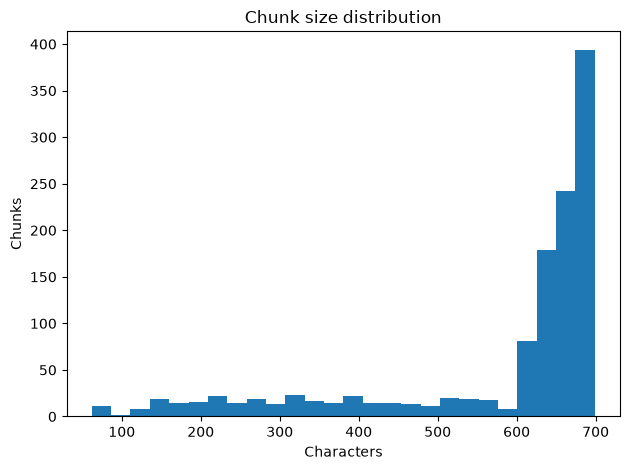

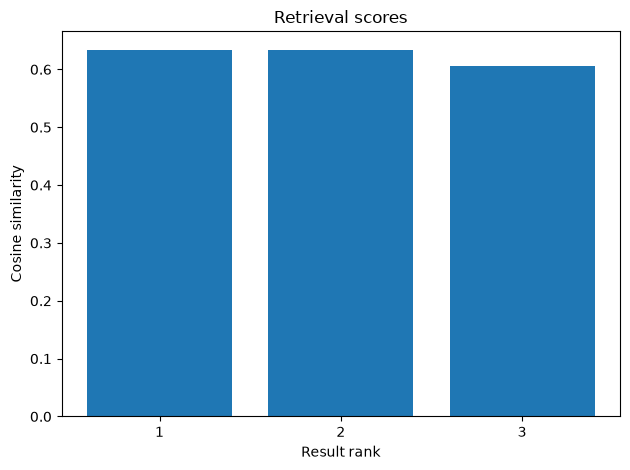

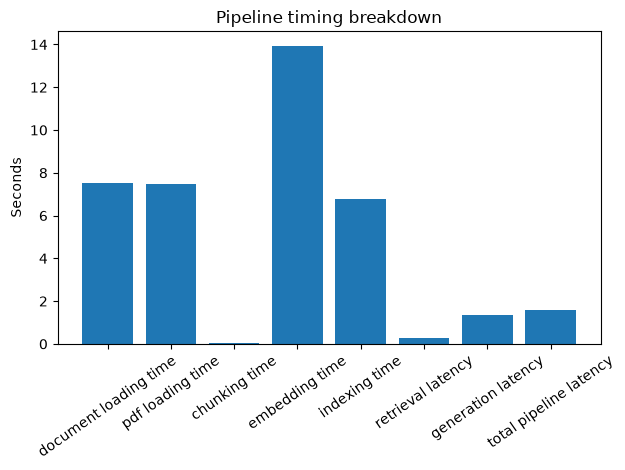

In [22]:
plot_chunk_size_distribution(chunks)
plot_retrieval_scores(retrieved)
plot_timing_breakdown(benchmark_metrics)
plt.show()

## 6. Benchmark

The timing table reports document loading, optional PDF loading, chunking, embedding, indexing, retrieval, generation, and total query latency when available. Compare runs only on the same hardware and corpus.

Production evaluation must additionally measure correctness, retrieval relevance, citation accuracy, hallucination risk, token usage, and local hardware feasibility.

In [23]:
print_benchmark_table(benchmark_metrics)

Pipeline step                 Seconds
-------------------------------------
Document loading               7.5033
PDF loading                    7.4978
Chunking                       0.0384
Embedding                     13.9189
Indexing                       6.7588
Retrieval                      0.2726
Generation                     1.3317
Total pipeline                 1.6043


## 7. Advantages

- Documents, vectors, prompts, and inference remain local.
- Retrieval is independent of the configured local language model.
- Bounded context reduces token usage and unsupported generation.
- Source, page, chunk, and score metadata remain inspectable.
- Reusable code stays in importable modules instead of notebook cells.
- The same components can support later evaluation and backend services.

## 8. Limitations

- Dense retrieval can miss exact identifiers and keyword matches.
- No authorization filter, reranker, query transformation, or conflict detector is applied.
- Docling output may not retain page boundaries; PyMuPDF provides page-level text when used.
- Scanned PDFs require a separately approved local OCR configuration.
- Similarity scores are not calibrated confidence values.
- Citations are mapped but not independently verified.
- Embedded Qdrant supports one process per storage path.

## 9. Enterprise Considerations

Production ingestion must validate department, document type, asset, location, version, date, owner, access level, and retention metadata. Retrieval must enforce role and department authorization before evidence reaches generation. Real CIAL documents must remain in controlled ignored storage and must never be uploaded externally.

Operational promotion also requires version-aware indexing, duplicate detection, audit logs, encryption, backup and recovery, citation verification, weak or conflicting evidence handling, and tests against long manuals, tables, scans, acronyms, and airport terminology. Multi-process backends should use Qdrant server mode.

## 10. What We'll Improve Next

The next experiment will add local query transformations while preserving the same loaders, chunking, embeddings, vector store, retrieval schema, and grounded-generation interface. Later work will compare hybrid vector/BM25 retrieval, metadata filters, local reranking, citation verification, and contradictory-evidence handling against this baseline.